# MLP: KenPom / BartTorvik matchup features

This notebook predicts tournament point differential using pairwise difference features between Team 1 and Team 2 from season-level ratings (KenPom / BartTorvik style), then a small multi-layer perceptron regressor.

### Features
For each stat $c$ in the chosen set:
$$\text{DIFF}_c = T1_c - T2_c$$
so each row is an 8-dimensional vector $\mathbf{x}$ encoding relative strength on each dimension for that year’s matchup.

### Preprocessing
- Train/test split by chronological year (80:20 on years) to match time series split.
- Standardize $\mathbf{x}$ using training-year means and variances only, then apply the same transform to test years.

### Model
Hidden layer with activation function (final configuration uses ReLU), scalar output with linear activation (regression):
$$\mathbf{h} = \langle W^{(1)}\mathbf{x}\rangle _+, \qquad f_w(x) = \mathbf{w}^{(2)\top}\mathbf{h}$$

### Training
Weights are fit by minimizing mean squared error on training games (learning rate, width, depth, epochs chosen by hyperparameter tuning with cross validation).

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
games = pd.read_csv("Dataset/Tournament Game Point Differentials.csv")
print(games.shape)
print(games.columns)
games.head()

(1070, 9)
Index(['YEAR', 'CURRENT_ROUND', 'TEAM1_ID', 'TEAM1', 'TEAM1_SCORE', 'TEAM2_ID',
       'TEAM2', 'TEAM2_SCORE', 'POINT_DIFFERENTIAL'],
      dtype='object')


,YEAR,CURRENT_ROUND,TEAM1_ID,TEAM1,TEAM1_SCORE,TEAM2_ID,TEAM2,TEAM2_SCORE,POINT_DIFFERENTIAL
0,2008,2,37,Memphis,68,43,Kansas,75,-7
1,2008,4,13,UCLA,63,37,Memphis,78,-15
2,2008,4,43,Kansas,84,31,North Carolina,66,18
3,2008,8,1,Xavier,57,13,UCLA,76,-19
4,2008,8,15,Texas,67,37,Memphis,85,-18


In [3]:
kpb = pd.read_csv("Dataset/KenPom Barttorvik.csv")
print(kpb.shape)
print(kpb.columns[:20])
kpb.head()

(1147, 103)
Index(['YEAR', 'CONF', 'CONF ID', 'QUAD NO', 'QUAD ID', 'TEAM NO', 'TEAM ID',
       'TEAM', 'SEED', 'ROUND', 'K TEMPO', 'K TEMPO RANK', 'KADJ T',
       'KADJ T RANK', 'K OFF', 'KO RANK', 'KADJ O', 'KADJ O RANK', 'K DEF',
       'KD RANK'],
      dtype='object')


,YEAR,CONF,CONF ID,QUAD NO,QUAD ID,TEAM NO,TEAM ID,TEAM,SEED,ROUND,...,BADJT RANK,AVG HGT RANK,EFF HGT RANK,EXP RANK,TALENT RANK,FT% RANK,OP FT% RANK,PPPO RANK,PPPD RANK,ELITE SOS RANK
0,2025,MAC,17,66,2,1147,2,Akron,13,64,...,19,361,364,73,149,86,239,25,145,305
1,2025,SEC,28,66,2,1146,3,Alabama,2,8,...,1,57,4,261,32,211,92,9,174,1
2,2025,SWAC,31,68,4,1145,4,Alabama St.,16,64,...,154,285,239,83,251,270,61,227,147,253
3,2025,Pat,25,66,2,1144,6,American,16,68,...,349,303,248,181,364,58,34,218,163,329
4,2025,B12,7,66,2,1143,8,Arizona,4,16,...,52,74,129,225,16,18,143,25,87,3


In [4]:
# combine the two datasets to use additional features from kenpom barttorvik
kpb_features = ["KADJ O", "KADJ D", "BARTHAG", "SEED", "EXP", "TALENT", "ELITE SOS", "BADJ T"]
kpb_stats = kpb[["YEAR", "TEAM"] + kpb_features].copy()

# merge team1 stats (YEAR + TEAM1)
team1_stats = kpb_stats.add_prefix("T1_").rename(columns={"T1_YEAR": "YEAR", "T1_TEAM": "TEAM1"})
merged = games.merge(team1_stats, on=["YEAR", "TEAM1"])

# merge team2 stats (YEAR + TEAM2)
team2_stats = kpb_stats.add_prefix("T2_").rename(columns={"T2_YEAR": "YEAR", "T2_TEAM": "TEAM2"})
merged = merged.merge(team2_stats, on=["YEAR", "TEAM2"])

# build difference features between teams
feature_cols = []
for c in kpb_features:
    out = f"DIFF_{c}"
    merged[out] = merged[f"T1_{c}"] - merged[f"T2_{c}"]
    feature_cols.append(out)

matchup_df = merged[["YEAR", "CURRENT_ROUND", "TEAM1", "TEAM2", "POINT_DIFFERENTIAL"] + feature_cols].copy()

print(matchup_df.shape)
matchup_df.head()

(1061, 13)


,YEAR,CURRENT_ROUND,TEAM1,TEAM2,POINT_DIFFERENTIAL,DIFF_KADJ O,DIFF_KADJ D,DIFF_BARTHAG,DIFF_SEED,DIFF_EXP,DIFF_TALENT,DIFF_ELITE SOS,DIFF_BADJ T
0,2008,2,Memphis,Kansas,-7,-6.738,-2.1512,-0.012,0,-0.442,-6.638,-9.402,1.2
1,2008,4,UCLA,Memphis,-15,4.040,2.8431,-0.003,0,-0.114,-4.526,11.474,-4.5
2,2008,4,Kansas,North Carolina,18,0.747,-5.0734,0.025,0,0.452,-1.273,-1.271,-5.6
3,2008,8,Xavier,UCLA,-19,-2.322,5.9080,-0.039,2,0.547,-65.139,-8.990,-0.4
4,2008,8,Texas,Memphis,-18,5.062,9.5892,-0.028,1,-0.376,-1.228,13.903,-5.9


In [5]:
# train/test split (80:20) by chronological year (matchs up with time series split) for cross validation
years = sorted(matchup_df["YEAR"].unique())
cutoff = int(np.ceil(0.8 * len(years)))
train_year_list = years[:cutoff]
test_year_list = years[cutoff:]

print("train:", train_year_list)
print("test:", test_year_list)

train_df = matchup_df[matchup_df["YEAR"].isin(train_year_list)].copy()
test_df = matchup_df[matchup_df["YEAR"].isin(test_year_list)].copy()

# separate target and features
X_train = train_df[feature_cols].to_numpy(dtype=float)
y_train = train_df[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

X_test = test_df[feature_cols].to_numpy(dtype=float)
y_test = test_df[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

# standardize using TRAIN statistics only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

train: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022]
test: [2023, 2024, 2025]
X_train: (876, 8)
y_train: (876, 1)
X_test: (185, 8)
y_test: (185, 1)


In [6]:
# ReLU activation function + its derivative
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)

In [7]:
# tanh activation function + its derivative
def tanh(x):
    return np.tanh(x)


def tanh_derivative(x):
    return 1.0 - (np.tanh(x))**2

In [8]:
# sigmoid activation function + its derivative
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def sigmoid_derivative(x):
    return sigmoid(x) * (1.0 - sigmoid(x))

In [9]:
activations = {
    "relu": relu,
    "tanh": tanh,
    "sigmoid": sigmoid,
}

activation_derivatives = {
    "relu": relu_derivative,
    "tanh": tanh_derivative,
    "sigmoid": sigmoid_derivative,
}

In [10]:
# forward pass of MLP
def forward_pass(X, weights, biases, activations):
    # outputs of each layer
    layers_inputs = [X]
    # pre-activation values of each layer
    layers_logits = []

    next_layer_inputs = X
    # process through hidden layers (dot product + bias then activation)
    for layer in range(len(weights) - 1):
        logits = next_layer_inputs.dot(weights[layer]) + biases[layer]
        layers_logits.append(logits)
        next_layer_inputs = activations[layer](logits)
        layers_inputs.append(next_layer_inputs)

    # output layer for predictions (regression so uses linear activation)
    predictions = next_layer_inputs.dot(weights[-1]) + biases[-1]
    layers_logits.append(predictions)

    return layers_inputs, layers_logits, predictions

In [11]:
# backprop 
def back_propagation(layers_inputs, layers_logits, predictions, y, weights, biases, learning_rate, activation_derivatives, l2_reg):
    n = y.shape[0]
    num_layers = len(weights)

    # dL/dy_hat for MSE = 2/n * (y_hat - y)
    error = (2.0 / n) * (predictions - y)

    # gradients for weights and biases
    weights_gradient = [None] * num_layers
    biases_gradient = [None] * num_layers

    # iterate backwards through layers to calculate gradients
    for layer in range(num_layers - 1, -1, -1):
        prev_layer_outputs = layers_inputs[layer]
        weights_gradient[layer] = prev_layer_outputs.T.dot(error) + (2.0 * l2_reg * weights[layer])
        biases_gradient[layer] = np.sum(error, axis=0, keepdims=True)

        # propagate error backward if not at first layer
        if layer > 0:
            error = error.dot(weights[layer].T) * activation_derivatives[layer - 1](layers_logits[layer - 1])

    # gradient descent updates
    for layer in range(num_layers):
        weights[layer] -= learning_rate * weights_gradient[layer]
        biases[layer] -= learning_rate * biases_gradient[layer]

    return weights, biases

In [12]:
# initialize weights/biases
def init_weights_biases(num_features, hidden_layer_sizes):
    # list of layer sizes (input layer, hidden layers, and output layer)
    layer_sizes = [num_features] + hidden_layer_sizes + [1]
    weights = []
    biases = []
    for input_size, output_size in zip(layer_sizes[:-1], layer_sizes[1:]):
        # small random values to initialize weights
        W = 0.01 * np.random.randn(input_size, output_size)
        b = np.zeros((1, output_size))
        weights.append(W)
        biases.append(b)

    return weights, biases

In [13]:
# predict + evaluate
def MLP_predict_regression(X, weights, biases, activations):
    return forward_pass(X, weights, biases, activations)[2]

In [14]:
# training function for MLP
def MLP_train_regression(X, y, hidden_layer_sizes, learning_rate, epochs, layer_activations=None, batch_size=None, lr_decay=0.0, l2_reg=0.0, verbose=20):
    # initialize weights/biases
    num_features = X.shape[1]
    weights, biases = init_weights_biases(num_features, hidden_layer_sizes)

    # if no layer activations are provided, use relu for all layers
    if layer_activations is None:
        layer_activations = ["relu"] * len(hidden_layer_sizes)

    # define activation functions and their derivatives for each layer (except output layer)
    hidden_activations = [activations[name] for name in layer_activations]
    hidden_activation_derivatives = [activation_derivatives[name] for name in layer_activations]

    # batch gradient descent setup
    n = X.shape[0]
    use_batch = batch_size is not None and batch_size < n
    step = batch_size if use_batch else n

    # iterate through the epochs and adjust the weights/biases to learn
    for epoch in range(epochs):
        # learning rate decay
        learning_rate *= (1.0 - lr_decay)

        if use_batch:
            # shuffle the data
            indices = np.random.permutation(n)
            X_epoch = X[indices]
            y_epoch = y[indices]
        else:
            X_epoch = X
            y_epoch = y

        # iterate through the batches
        for start in range(0, n, step):
            end = min(start + step, n)
            X_batch = X_epoch[start:end]
            y_batch = y_epoch[start:end]

            # forward pass to get predictions
            layers_inputs, layers_logits, predictions = forward_pass(X_batch, weights, biases, activations=hidden_activations)
            # backward pass to find error and adjust weights/biases
            weights, biases = back_propagation(layers_inputs, layers_logits, predictions, y_batch, weights, biases, learning_rate, activation_derivatives=hidden_activation_derivatives, l2_reg=l2_reg)

        # print the MAE every given number of epochs
        if epoch % verbose == 0:
            predictions = MLP_predict_regression(X, weights, biases, activations=hidden_activations)
            mae = np.mean(np.abs(predictions - y))
            print("epoch: ", epoch, " train MAE: ", mae)

    return weights, biases, hidden_activations

In [15]:
np.random.seed(42)
# train MLP
weights, biases, hidden_activations = MLP_train_regression(X_train, y_train, hidden_layer_sizes=[8], learning_rate=1e-3, epochs=10000, layer_activations=None, batch_size=None, lr_decay=0.0, l2_reg=0.0, verbose=500)
# predict on test set
predictions_test = MLP_predict_regression(X_test, weights, biases, activations=hidden_activations)
# evaluate test set
test_mae = float(np.mean(np.abs(predictions_test - y_test)))
test_rmse = float(np.sqrt(np.mean((predictions_test - y_test) ** 2)))

print()
print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)

epoch:  0  train MAE:  11.965774370747368
epoch:  500  train MAE:  9.422456357235662
epoch:  1000  train MAE:  9.06363067332344
epoch:  1500  train MAE:  8.999633357803809
epoch:  2000  train MAE:  8.991461977657897
epoch:  2500  train MAE:  8.98725410999519
epoch:  3000  train MAE:  8.987597873558883
epoch:  3500  train MAE:  8.9888714399297
epoch:  4000  train MAE:  8.990704748021459
epoch:  4500  train MAE:  8.989379362966789
epoch:  5000  train MAE:  8.986390693421873
epoch:  5500  train MAE:  8.979454763328507
epoch:  6000  train MAE:  8.967893823125374
epoch:  6500  train MAE:  8.956456725895636
epoch:  7000  train MAE:  8.946085350754256
epoch:  7500  train MAE:  8.928311616787278
epoch:  8000  train MAE:  8.913986238151624
epoch:  8500  train MAE:  8.89880107304057
epoch:  9000  train MAE:  8.882057104709656
epoch:  9500  train MAE:  8.873264516486229

Test MAE: 9.121150362255698
Test RMSE: 11.422824859786402


lr = 0.0001
epoch:  0  train MAE:  11.967915277318793
epoch:  1000  train MAE:  11.752875130840724
epoch:  2000  train MAE:  11.598848441072354
epoch:  3000  train MAE:  10.607992642734676
epoch:  4000  train MAE:  9.567351439442334
epoch:  5000  train MAE:  9.421235404731839
epoch:  6000  train MAE:  9.233630874342019
epoch:  7000  train MAE:  9.13815432830436
epoch:  8000  train MAE:  9.102453575445193
epoch:  9000  train MAE:  9.079470485326077
lr = 0.000177828
epoch:  0  train MAE:  11.967683608226293
epoch:  1000  train MAE:  10.654675218617468
epoch:  2000  train MAE:  9.507988132606346
epoch:  3000  train MAE:  9.424390297571367
epoch:  4000  train MAE:  9.226195161247297
epoch:  5000  train MAE:  9.05338401036501
epoch:  6000  train MAE:  9.010921980671796
epoch:  7000  train MAE:  8.996594832881204
epoch:  8000  train MAE:  8.991544924240166
epoch:  9000  train MAE:  8.987241309921313
lr = 0.000316228
epoch:  0  train MAE:  11.967410399414849
epoch:  1000  train MAE:  11.44839

,hidden,lr,epochs,test_mae
0,[8],0.000100,10000,9.345311
1,[8],0.000178,10000,9.281453
2,[8],0.000316,10000,9.296820
3,[8],0.000562,10000,9.329219
4,[8],0.001000,10000,9.256507
5,[8],0.001778,10000,9.338257
6,[8],0.003162,10000,9.376037
7,[8],0.005623,10000,9.429283
8,[8],0.010000,10000,9.564787


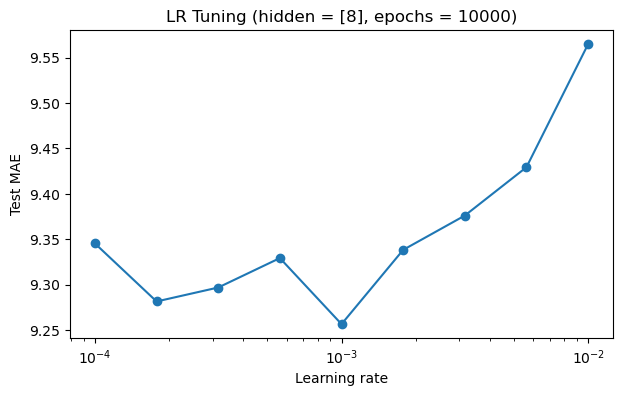

In [16]:
# learning-rate hyperparameter tuning
hidden = [8]
learning_rates = np.logspace(-4, -2, 9)  # 1e-4 to 1e-2
epochs = 10000

np.random.seed(42)  # keep seed constant (reproducible)

rows = []
for lr in learning_rates:
    print(f"lr = {lr:g}")

    weights, biases, hidden_activations = MLP_train_regression(
        X_train, y_train,
        hidden_layer_sizes=hidden,
        learning_rate=float(lr),
        epochs=epochs,
        layer_activations=None,
        batch_size=None,
        lr_decay=0.0,
        l2_reg=0.0,
        verbose=1000
    )

    preds_test = MLP_predict_regression(X_test, weights, biases, activations=hidden_activations)
    test_mae = float(np.mean(np.abs(preds_test - y_test)))

    rows.append({"hidden": str(hidden), "lr": float(lr), "epochs": epochs, "test_mae": test_mae})

results_df = pd.DataFrame(rows)
display(results_df)

plt.figure(figsize=(7, 4))
plt.plot(results_df["lr"], results_df["test_mae"], marker="o")
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Test MAE")
plt.title(f"LR Tuning (hidden = {hidden}, epochs = {epochs})")
plt.show()

epochs = 1000
epoch:  0  train MAE:  11.965774370747368
epoch:  500  train MAE:  9.422456357235662
epochs = 2000
epoch:  0  train MAE:  11.965774370747368
epoch:  500  train MAE:  9.422456357235662
epoch:  1000  train MAE:  9.06363067332344
epoch:  1500  train MAE:  8.999633357803809
epochs = 4000
epoch:  0  train MAE:  11.965774370747368
epoch:  500  train MAE:  9.422456357235662
epoch:  1000  train MAE:  9.06363067332344
epoch:  1500  train MAE:  8.999633357803809
epoch:  2000  train MAE:  8.991461977657897
epoch:  2500  train MAE:  8.98725410999519
epoch:  3000  train MAE:  8.987597873558883
epoch:  3500  train MAE:  8.9888714399297
epochs = 6000
epoch:  0  train MAE:  11.965774370747368
epoch:  500  train MAE:  9.422456357235662
epoch:  1000  train MAE:  9.06363067332344
epoch:  1500  train MAE:  8.999633357803809
epoch:  2000  train MAE:  8.991461977657897
epoch:  2500  train MAE:  8.98725410999519
epoch:  3000  train MAE:  8.987597873558883
epoch:  3500  train MAE:  8.98887143992

,epochs,hidden,lr,test_mae
0,1000,[8],0.001,9.344562
1,2000,[8],0.001,9.327906
2,4000,[8],0.001,9.320252
3,6000,[8],0.001,9.262062
4,8000,[8],0.001,9.209682
5,10000,[8],0.001,9.121150
6,12500,[8],0.001,9.096996
7,15000,[8],0.001,9.097800
8,17500,[8],0.001,9.151546


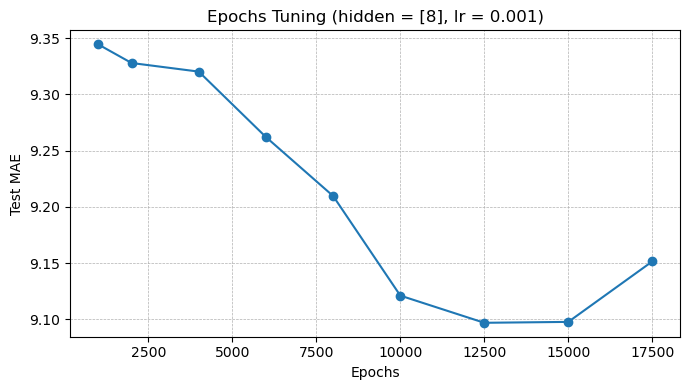

In [17]:
# epochs tuning
hidden = [8]
layer_activations = ["relu"] * len(hidden)
lr = 1e-3

epoch_list = [1000, 2000, 4000, 6000, 8000, 10000, 12500,15000, 17500]

np.random.seed(42)

rows = []
for ep in epoch_list:
    print(f"epochs = {ep}")

    np.random.seed(42)
    w, b, hidden_acts = MLP_train_regression(
        X_train, y_train,
        hidden_layer_sizes=hidden,
        learning_rate=lr,
        epochs=ep,
        layer_activations=layer_activations,
        batch_size=None,
        lr_decay=0.0,
        l2_reg=0.0,
        verbose=500
    )

    preds_test = MLP_predict_regression(X_test, w, b, activations=hidden_acts)
    test_mae = float(np.mean(np.abs(preds_test - y_test)))

    rows.append({"epochs": ep, "hidden": str(hidden), "lr": lr, "test_mae": test_mae})

epochs_df = pd.DataFrame(rows)
display(epochs_df)

plt.figure(figsize=(7, 4))
plt.plot(epochs_df["epochs"], epochs_df["test_mae"], marker="o")
plt.xlabel("Epochs")
plt.ylabel("Test MAE")
plt.title(f"Epochs Tuning (hidden = {hidden}, lr = {lr:g})")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

hidden = [8]
epoch:  0  train MAE:  11.965774370747368
epoch:  1000  train MAE:  9.06363067332344
epoch:  2000  train MAE:  8.991461977657897
epoch:  3000  train MAE:  8.987597873558883
epoch:  4000  train MAE:  8.990704748021459
epoch:  5000  train MAE:  8.986390693421873
epoch:  6000  train MAE:  8.967893823125374
epoch:  7000  train MAE:  8.946085350754256
epoch:  8000  train MAE:  8.913986238151624
epoch:  9000  train MAE:  8.882057104709656
epoch:  10000  train MAE:  8.867415282078142
epoch:  11000  train MAE:  8.857248248295491
epoch:  12000  train MAE:  8.850336183350501
hidden = [16]
epoch:  0  train MAE:  11.965601156135355
epoch:  1000  train MAE:  9.01176052264432
epoch:  2000  train MAE:  8.979056599026961
epoch:  3000  train MAE:  8.952462832001151
epoch:  4000  train MAE:  8.928141139692523
epoch:  5000  train MAE:  8.906864919781093
epoch:  6000  train MAE:  8.877454342845686
epoch:  7000  train MAE:  8.842062871468116
epoch:  8000  train MAE:  8.812255702773776
epoch:  

,hidden,lr,epochs,test_mae
0,[8],0.001,12500,9.096996
1,[16],0.001,12500,9.283341
2,[32],0.001,12500,9.258597
3,[64],0.001,12500,9.235750
4,"[32, 16]",0.001,12500,10.532201
5,"[64, 32]",0.001,12500,10.551357
6,"[64, 32, 16]",0.001,12500,11.567997


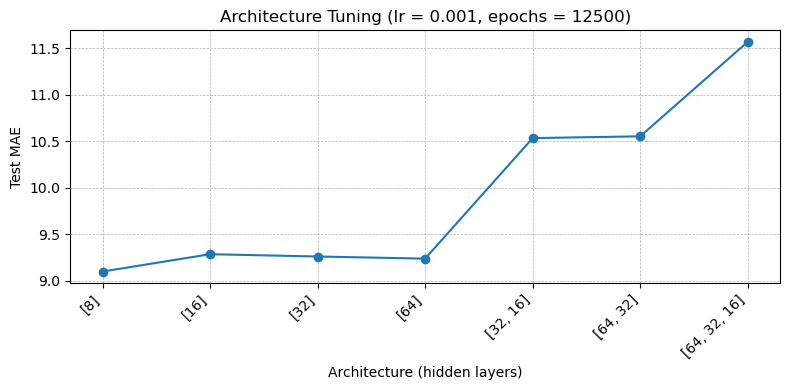

In [18]:
# architecture tuning
architectures = [[8], [16], [32], [64], [32, 16], [64, 32], [64, 32, 16]]
best_lr = float(results_df.loc[results_df["test_mae"].idxmin(), "lr"])
epochs = 12500

np.random.seed(42)

rows = []
for hidden in architectures:
    print(f"hidden = {hidden}")

    weights, biases, hidden_activations = MLP_train_regression(
        X_train, y_train,
        hidden_layer_sizes=hidden,
        learning_rate=best_lr,
        epochs=epochs,
        layer_activations=None,
        batch_size=None,
        lr_decay=0.0,
        l2_reg=0.0,
        verbose=1000
    )

    preds_test = MLP_predict_regression(X_test, weights, biases, activations=hidden_activations)
    test_mae = float(np.mean(np.abs(preds_test - y_test)))

    rows.append({"hidden": str(hidden), "lr": best_lr, "epochs": epochs, "test_mae": test_mae})

arch_df = pd.DataFrame(rows)
display(arch_df)

plt.figure(figsize=(8, 4))
x = np.arange(len(architectures))
plt.plot(x, arch_df["test_mae"], marker="o")
plt.xticks(x, [str(a) for a in architectures], rotation=45, ha="right")
plt.xlabel("Architecture (hidden layers)")
plt.ylabel("Test MAE")
plt.title(f"Architecture Tuning (lr = {best_lr:g}, epochs = {epochs})")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

activation = relu
epoch:  0  train MAE:  11.965774370747368
epoch:  1000  train MAE:  9.06363067332344
epoch:  2000  train MAE:  8.991461977657897
epoch:  3000  train MAE:  8.987597873558883
epoch:  4000  train MAE:  8.990704748021459
epoch:  5000  train MAE:  8.986390693421873
epoch:  6000  train MAE:  8.967893823125374
epoch:  7000  train MAE:  8.946085350754256
epoch:  8000  train MAE:  8.913986238151624
epoch:  9000  train MAE:  8.882057104709656
epoch:  10000  train MAE:  8.867415282078142
epoch:  11000  train MAE:  8.857248248295491
epoch:  12000  train MAE:  8.850336183350501
activation = tanh
epoch:  0  train MAE:  11.965785527215187
epoch:  1000  train MAE:  9.106908829362268
epoch:  2000  train MAE:  9.008433034376088
epoch:  3000  train MAE:  8.907762984900979
epoch:  4000  train MAE:  8.780735447342709
epoch:  5000  train MAE:  8.69618804164456
epoch:  6000  train MAE:  8.633411189342267
epoch:  7000  train MAE:  8.585545620893377
epoch:  8000  train MAE:  8.53560802743696


,activation,hidden,lr,epochs,test_mae
0,relu,[8],0.001,12500,9.096996
1,tanh,[8],0.001,12500,9.787663
2,sigmoid,[8],0.001,12500,9.422773


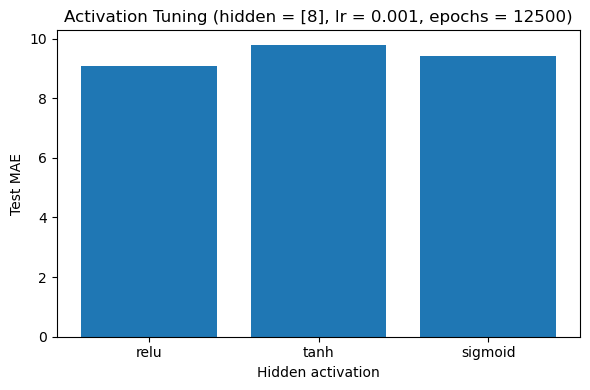

In [19]:
# activation tuning
hidden = [8]
lr = 1e-3
epochs = 12500

activation_names = ["relu", "tanh", "sigmoid"]

np.random.seed(42)

rows = []
for act in activation_names:
    print(f"activation = {act}")

    weights, biases, hidden_activations = MLP_train_regression(
        X_train, y_train,
        hidden_layer_sizes=hidden,
        learning_rate=lr,
        epochs=epochs,
        layer_activations=[act] * len(hidden),
        batch_size=None,
        lr_decay=0.0,
        l2_reg=0.0,
        verbose=1000
    )

    preds_test = MLP_predict_regression(X_test, weights, biases, activations=hidden_activations)
    test_mae = float(np.mean(np.abs(preds_test - y_test)))

    rows.append({"activation": act, "hidden": str(hidden), "lr": lr, "epochs": epochs, "test_mae": test_mae})

act_df = pd.DataFrame(rows)
display(act_df)

plt.figure(figsize=(6, 4))
plt.bar(act_df["activation"], act_df["test_mae"])
plt.xlabel("Hidden activation")
plt.ylabel("Test MAE")
plt.title(f"Activation Tuning (hidden = {hidden}, lr = {lr:g}, epochs = {epochs})")
plt.tight_layout()
plt.show()

batch_size = None
epoch:  0  train MAE:  11.965774370747368
epoch:  1000  train MAE:  9.06363067332344
epoch:  2000  train MAE:  8.991461977657897
epoch:  3000  train MAE:  8.987597873558883
epoch:  4000  train MAE:  8.990704748021459
epoch:  5000  train MAE:  8.986390693421873
epoch:  6000  train MAE:  8.967893823125374
epoch:  7000  train MAE:  8.946085350754256
epoch:  8000  train MAE:  8.913986238151624
epoch:  9000  train MAE:  8.882057104709656
epoch:  10000  train MAE:  8.867415282078142
epoch:  11000  train MAE:  8.857248248295491
epoch:  12000  train MAE:  8.850336183350501
batch_size = 16
epoch:  0  train MAE:  11.842870244469847
epoch:  1000  train MAE:  8.590528707251547
epoch:  2000  train MAE:  8.570263854729513
epoch:  3000  train MAE:  8.558764465368588
epoch:  4000  train MAE:  8.58251578766643
epoch:  5000  train MAE:  8.574799175787854
epoch:  6000  train MAE:  8.547276427880517
epoch:  7000  train MAE:  8.619624924107734
epoch:  8000  train MAE:  8.520576601065708
e

,batch_size,hidden,lr,epochs,test_mae
0,full,[8],0.001,12500,9.096996
1,16,[8],0.001,12500,10.018840
2,32,[8],0.001,12500,9.304047
3,64,[8],0.001,12500,9.619715
4,128,[8],0.001,12500,9.647147


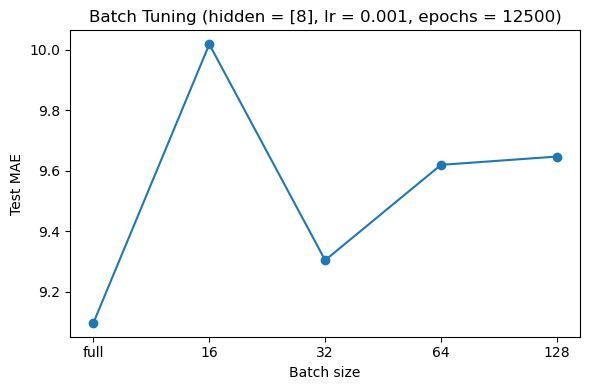

In [20]:
# batch tuning
hidden = [8]
lr = 1e-3
epochs = 12500
layer_activations = ["relu"] * len(hidden)

batch_sizes = [None, 16, 32, 64, 128]

np.random.seed(42)

rows = []
for bs in batch_sizes:
    print(f"batch_size = {bs}")

    weights, biases, hidden_activations = MLP_train_regression(
        X_train, y_train,
        hidden_layer_sizes=hidden,
        learning_rate=lr,
        epochs=epochs,
        layer_activations=layer_activations,
        batch_size=bs,
        lr_decay=0.0,
        l2_reg=0.0,
        verbose=1000
    )

    preds_test = MLP_predict_regression(X_test, weights, biases, activations=hidden_activations)
    test_mae = float(np.mean(np.abs(preds_test - y_test)))

    rows.append({
        "batch_size": "full" if bs is None else int(bs),
        "hidden": str(hidden),
        "lr": lr,
        "epochs": epochs,
        "test_mae": test_mae
    })

mb_df = pd.DataFrame(rows)
display(mb_df)

plt.figure(figsize=(6, 4))
labels = [str(x) for x in mb_df["batch_size"]]
x = np.arange(len(labels))
plt.plot(x, mb_df["test_mae"], marker="o")
plt.xticks(x, labels)
plt.xlabel("Batch size")
plt.ylabel("Test MAE")
plt.title(f"Batch Tuning (hidden = {hidden}, lr = {lr:g}, epochs = {epochs})")
plt.tight_layout()
plt.show()

lr_decay = 0.0
epoch:  0  train MAE:  11.965774370747368
epoch:  1000  train MAE:  9.06363067332344
epoch:  2000  train MAE:  8.991461977657897
epoch:  3000  train MAE:  8.987597873558883
epoch:  4000  train MAE:  8.990704748021459
epoch:  5000  train MAE:  8.986390693421873
epoch:  6000  train MAE:  8.967893823125374
epoch:  7000  train MAE:  8.946085350754256
epoch:  8000  train MAE:  8.913986238151624
epoch:  9000  train MAE:  8.882057104709656
epoch:  10000  train MAE:  8.867415282078142
epoch:  11000  train MAE:  8.857248248295491
epoch:  12000  train MAE:  8.850336183350501
lr_decay = 0.001
epoch:  0  train MAE:  11.96572829526879
epoch:  1000  train MAE:  9.330277737938314
epoch:  2000  train MAE:  9.068458483364234
epoch:  3000  train MAE:  9.030287892837643
epoch:  4000  train MAE:  9.022663593960552
epoch:  5000  train MAE:  9.02050515087171
epoch:  6000  train MAE:  9.019781055954557
epoch:  7000  train MAE:  9.019523532700386
epoch:  8000  train MAE:  9.01942938946979
epoch

,lr_decay,hidden,lr,epochs,test_mae
0,0.000,[8],0.001,12500,9.096996
1,0.001,[8],0.001,12500,9.356743
2,0.005,[8],0.001,12500,12.556671
3,0.010,[8],0.001,12500,12.716770


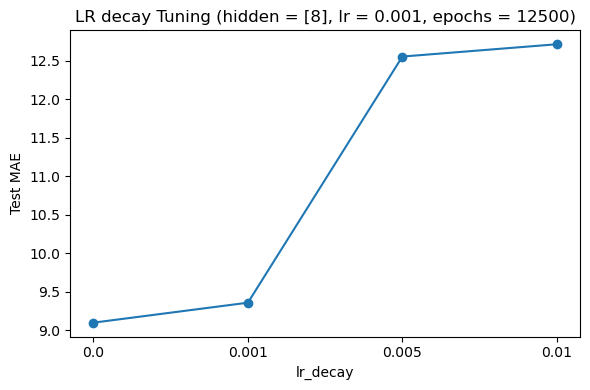

In [21]:
# learning-rate decay tuning
hidden = [8]
lr = 1e-3
epochs = 12500
layer_activations = ["relu"] * len(hidden)

lr_decays = [0.0, 0.001, 0.005, 0.01]

np.random.seed(42)

rows = []
for d in lr_decays:
    print(f"lr_decay = {d}")

    weights, biases, hidden_activations = MLP_train_regression(
        X_train, y_train,
        hidden_layer_sizes=hidden,
        learning_rate=lr,
        epochs=epochs,
        layer_activations=layer_activations,
        batch_size=None,
        lr_decay=float(d),
        l2_reg=0.0,
        verbose=1000
    )

    preds_test = MLP_predict_regression(X_test, weights, biases, activations=hidden_activations)
    test_mae = float(np.mean(np.abs(preds_test - y_test)))

    rows.append({
        "lr_decay": float(d),
        "hidden": str(hidden),
        "lr": lr,
        "epochs": epochs,
        "test_mae": test_mae
    })

decay_df = pd.DataFrame(rows)
display(decay_df)

plt.figure(figsize=(6, 4))
x = np.arange(len(lr_decays))
plt.plot(x, decay_df["test_mae"], marker="o")
plt.xticks(x, [str(d) for d in lr_decays])
plt.xlabel("lr_decay")
plt.ylabel("Test MAE")
plt.title(f"LR decay Tuning (hidden = {hidden}, lr = {lr:g}, epochs = {epochs})")
plt.tight_layout()
plt.show()

l2_reg = 0.0
epoch:  0  train MAE:  11.965774370747368
epoch:  1000  train MAE:  9.06363067332344
epoch:  2000  train MAE:  8.991461977657897
epoch:  3000  train MAE:  8.987597873558883
epoch:  4000  train MAE:  8.990704748021459
epoch:  5000  train MAE:  8.986390693421873
epoch:  6000  train MAE:  8.967893823125374
epoch:  7000  train MAE:  8.946085350754256
epoch:  8000  train MAE:  8.913986238151624
epoch:  9000  train MAE:  8.882057104709656
epoch:  10000  train MAE:  8.867415282078142
epoch:  11000  train MAE:  8.857248248295491
epoch:  12000  train MAE:  8.850336183350501
l2_reg = 1e-06
epoch:  0  train MAE:  11.965725914167905
epoch:  1000  train MAE:  9.019084235838044
epoch:  2000  train MAE:  8.977451046800695
epoch:  3000  train MAE:  8.950767798504158
epoch:  4000  train MAE:  8.928488646771578
epoch:  5000  train MAE:  8.91354760261601
epoch:  6000  train MAE:  8.892780658800062
epoch:  7000  train MAE:  8.888453760052872
epoch:  8000  train MAE:  8.887515802519502
epoch: 

,l2_reg,hidden,lr,epochs,test_mae
0,0.000000,[8],0.001,12500,9.096996
1,0.000001,[8],0.001,12500,9.256874
2,0.000010,[8],0.001,12500,9.288937
3,0.000100,[8],0.001,12500,9.278835
4,0.001000,[8],0.001,12500,9.263969
5,0.010000,[8],0.001,12500,9.301353
6,0.100000,[8],0.001,12500,9.276821
7,1.000000,[8],0.001,12500,9.354710


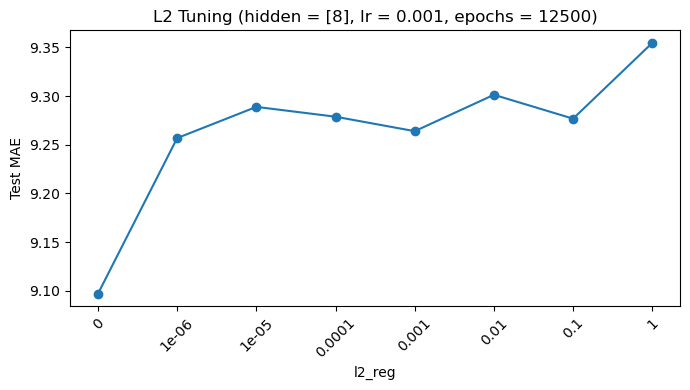

In [22]:
# L2 regularization tuning
hidden = [8]
lr = 1e-3
epochs = 12500
layer_activations = ["relu"] * len(hidden)

l2_regs = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]

np.random.seed(42)

rows = []
for l2 in l2_regs:
    print(f"l2_reg = {l2}")

    weights, biases, hidden_activations = MLP_train_regression(
        X_train, y_train,
        hidden_layer_sizes=hidden,
        learning_rate=lr,
        epochs=epochs,
        layer_activations=layer_activations,
        batch_size=None,
        lr_decay=0.0,
        l2_reg=float(l2),
        verbose=1000
    )

    preds_test = MLP_predict_regression(X_test, weights, biases, activations=hidden_activations)
    test_mae = float(np.mean(np.abs(preds_test - y_test)))

    rows.append({
        "l2_reg": float(l2),
        "hidden": str(hidden),
        "lr": lr,
        "epochs": epochs,
        "test_mae": test_mae
    })

l2_df = pd.DataFrame(rows)
display(l2_df)

plt.figure(figsize=(7, 4))
labels = [f"{v:g}" for v in l2_df["l2_reg"]]
x = np.arange(len(labels))
plt.plot(x, l2_df["test_mae"], marker="o")
plt.xticks(x, labels, rotation=45)
plt.xlabel("l2_reg")
plt.ylabel("Test MAE")
plt.title(f"L2 Tuning (hidden = {hidden}, lr = {lr:g}, epochs = {epochs})")
plt.tight_layout()
plt.show()

In [23]:
# AVG-only features
feature_cols_avg_only = []
for c in kpb_features:
    avg_c = f"AVG_{c}"
    merged[avg_c] = (merged[f"T1_{c}"] + merged[f"T2_{c}"]) / 2.0
    feature_cols_avg_only.append(avg_c)

matchup_df_avg_only = merged[
    ["YEAR", "CURRENT_ROUND", "TEAM1", "TEAM2", "POINT_DIFFERENTIAL"] + feature_cols_avg_only
].copy()
print("matchup_df_avg_only shape:", matchup_df_avg_only.shape)

# split (same year split as before)
train_df_avg_only = matchup_df_avg_only[matchup_df_avg_only["YEAR"].isin(train_year_list)].copy()
test_df_avg_only = matchup_df_avg_only[matchup_df_avg_only["YEAR"].isin(test_year_list)].copy()

X_train_avg_only = train_df_avg_only[feature_cols_avg_only].to_numpy(dtype=float)
y_train_avg_only = train_df_avg_only[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

X_test_avg_only = test_df_avg_only[feature_cols_avg_only].to_numpy(dtype=float)
y_test_avg_only = test_df_avg_only[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

scaler_avg_only = StandardScaler()
X_train_avg_only = scaler_avg_only.fit_transform(X_train_avg_only)
X_test_avg_only = scaler_avg_only.transform(X_test_avg_only)

print("X_train_avg_only:", X_train_avg_only.shape, "X_test_avg_only:", X_test_avg_only.shape)

matchup_df_avg_only shape: (1061, 13)
X_train_avg_only: (876, 8) X_test_avg_only: (185, 8)


In [24]:
# DIFF + AVG combined features
feature_cols_diff_avg = feature_cols + feature_cols_avg_only

matchup_df_diff_avg = merged[
    ["YEAR", "CURRENT_ROUND", "TEAM1", "TEAM2", "POINT_DIFFERENTIAL"] + feature_cols_diff_avg
].copy()
print("matchup_df_diff_avg shape:", matchup_df_diff_avg.shape)

# split (same year split as before)
train_df_diff_avg = matchup_df_diff_avg[matchup_df_diff_avg["YEAR"].isin(train_year_list)].copy()
test_df_diff_avg = matchup_df_diff_avg[matchup_df_diff_avg["YEAR"].isin(test_year_list)].copy()

X_train_diff_avg = train_df_diff_avg[feature_cols_diff_avg].to_numpy(dtype=float)
y_train_diff_avg = train_df_diff_avg[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

X_test_diff_avg = test_df_diff_avg[feature_cols_diff_avg].to_numpy(dtype=float)
y_test_diff_avg = test_df_diff_avg[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

scaler_diff_avg = StandardScaler()
X_train_diff_avg = scaler_diff_avg.fit_transform(X_train_diff_avg)
X_test_diff_avg = scaler_diff_avg.transform(X_test_diff_avg)

print("X_train_diff_avg:", X_train_diff_avg.shape, "X_test_diff_avg:", X_test_diff_avg.shape)

matchup_df_diff_avg shape: (1061, 21)
X_train_diff_avg: (876, 16) X_test_diff_avg: (185, 16)


In [25]:
# baseline season-avg PD feature (DIFF_AVG_PD)
teams = pd.read_csv("Dataset/MTeams.csv")
regular = pd.read_csv("Dataset/MRegularSeasonCompactResults.csv")
ncaa_tourney = pd.read_csv("Dataset/MNCAATourneyCompactResults.csv")

id_to_name = {r.TeamID: r.TeamName for r in teams.itertuples(index=False)}

# only keep March Madness teams
mm_teams = set()
for row in ncaa_tourney.itertuples(index=False):
    mm_teams.add((row.Season, id_to_name.get(row.WTeamID)))
    mm_teams.add((row.Season, id_to_name.get(row.LTeamID)))

# each team's avg point differential from regular season games
regular_margins = []
for row in regular.itertuples(index=False):
    margin = row.WScore - row.LScore
    winner = id_to_name.get(row.WTeamID)
    loser = id_to_name.get(row.LTeamID)
    if (row.Season, winner) in mm_teams:
        regular_margins.append({"YEAR": row.Season, "TEAM": winner, "MARGIN": margin})
    if (row.Season, loser) in mm_teams:
        regular_margins.append({"YEAR": row.Season, "TEAM": loser, "MARGIN": -margin})

regular_margins = pd.DataFrame(regular_margins)
season_avg_df = regular_margins.groupby(["YEAR", "TEAM"], as_index=False)["MARGIN"].mean()
season_avg = {(r.YEAR, r.TEAM): r.MARGIN for r in season_avg_df.itertuples(index=False)}

# attach baseline features to your merged matchups (TEAM1/TEAM2 are names)
baseline_df = merged[["YEAR", "CURRENT_ROUND", "TEAM1", "TEAM2", "POINT_DIFFERENTIAL"]].copy()
baseline_df["TEAM1_AVG_PD"] = baseline_df.apply(lambda r: season_avg.get((r["YEAR"], r["TEAM1"])), axis=1)
baseline_df["TEAM2_AVG_PD"] = baseline_df.apply(lambda r: season_avg.get((r["YEAR"], r["TEAM2"])), axis=1)

baseline_df = baseline_df.dropna(subset=["TEAM1_AVG_PD", "TEAM2_AVG_PD"]).copy()
baseline_df["DIFF_AVG_PD"] = baseline_df["TEAM1_AVG_PD"] - baseline_df["TEAM2_AVG_PD"]

baseline_feature_cols = ["DIFF_AVG_PD"]

print("baseline_df shape:", baseline_df.shape)

# Re-split using the SAME year split as before
train_df3 = baseline_df[baseline_df["YEAR"].isin(train_year_list)].copy()
test_df3 = baseline_df[baseline_df["YEAR"].isin(test_year_list)].copy()

X_train_baseline = train_df3[baseline_feature_cols].to_numpy(dtype=float)
y_train_baseline = train_df3[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

X_test_baseline = test_df3[baseline_feature_cols].to_numpy(dtype=float)
y_test_baseline = test_df3[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

scaler3 = StandardScaler()
X_train_baseline = scaler3.fit_transform(X_train_baseline)
X_test_baseline = scaler3.transform(X_test_baseline)

print("X_train_baseline:", X_train_baseline.shape, "X_test_baseline:", X_test_baseline.shape)

baseline_df shape: (639, 8)
X_train_baseline: (529, 1) X_test_baseline: (110, 1)


In [26]:
# build DIFF (KPB) and DIFF_AVG_PD
hybrid_df = merged[["YEAR", "CURRENT_ROUND", "TEAM1", "TEAM2", "POINT_DIFFERENTIAL"] + feature_cols].copy()

# add DIFF_AVG_PD from season_avg
hybrid_df["TEAM1_AVG_PD"] = hybrid_df.apply(lambda r: season_avg.get((r["YEAR"], r["TEAM1"])), axis=1)
hybrid_df["TEAM2_AVG_PD"] = hybrid_df.apply(lambda r: season_avg.get((r["YEAR"], r["TEAM2"])), axis=1)
hybrid_df = hybrid_df.dropna(subset=["TEAM1_AVG_PD", "TEAM2_AVG_PD"]).copy()
hybrid_df["DIFF_AVG_PD"] = hybrid_df["TEAM1_AVG_PD"] - hybrid_df["TEAM2_AVG_PD"]

hybrid_feature_cols = feature_cols + ["DIFF_AVG_PD"]

print("hybrid_df shape:", hybrid_df.shape)

# Re-split using the SAME year split as before
train_df4 = hybrid_df[hybrid_df["YEAR"].isin(train_year_list)].copy()
test_df4 = hybrid_df[hybrid_df["YEAR"].isin(test_year_list)].copy()

X_train_baseline_and_diff = train_df4[hybrid_feature_cols].to_numpy(dtype=float)
y_train_baseline_and_diff = train_df4[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

X_test_baseline_and_diff = test_df4[hybrid_feature_cols].to_numpy(dtype=float)
y_test_baseline_and_diff = test_df4[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

scaler4 = StandardScaler()
X_train_baseline_and_diff = scaler4.fit_transform(X_train_baseline_and_diff)
X_test_baseline_and_diff = scaler4.transform(X_test_baseline_and_diff)

print("X_train_baseline_and_diff:", X_train_baseline_and_diff.shape, "X_test_baseline_and_diff:", X_test_baseline_and_diff.shape)

hybrid_df shape: (639, 16)
X_train_baseline_and_diff: (529, 9) X_test_baseline_and_diff: (110, 9)


In [27]:
# DIFF(KPB) and CURRENT_ROUND 
round_feature_cols = feature_cols + ["CURRENT_ROUND"]

X_train_round = train_df[round_feature_cols].to_numpy(dtype=float)
y_train_round = train_df[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

X_test_round = test_df[round_feature_cols].to_numpy(dtype=float)
y_test_round = test_df[["POINT_DIFFERENTIAL"]].to_numpy(dtype=float)

scaler_round = StandardScaler()
X_train_round = scaler_round.fit_transform(X_train_round)
X_test_round = scaler_round.transform(X_test_round)

print("X_train_round:", X_train_round.shape, "X_test_round:", X_test_round.shape)

X_train_round: (876, 9) X_test_round: (185, 9)


epoch:  0  train MAE:  11.965774370747368
epoch:  1000  train MAE:  9.06363067332344
epoch:  2000  train MAE:  8.991461977657897
epoch:  3000  train MAE:  8.987597873558883
epoch:  4000  train MAE:  8.990704748021459
epoch:  5000  train MAE:  8.986390693421873
epoch:  6000  train MAE:  8.967893823125374
epoch:  7000  train MAE:  8.946085350754256
epoch:  8000  train MAE:  8.913986238151624
epoch:  9000  train MAE:  8.882057104709656
epoch:  10000  train MAE:  8.867415282078142
epoch:  11000  train MAE:  8.857248248295491
epoch:  12000  train MAE:  8.850336183350501
epoch:  0  train MAE:  11.965795442341745
epoch:  1000  train MAE:  10.007594933861714
epoch:  2000  train MAE:  9.91459624176305
epoch:  3000  train MAE:  9.783806219035306
epoch:  4000  train MAE:  9.739566801726482
epoch:  5000  train MAE:  9.71723498775845
epoch:  6000  train MAE:  9.698756047646286
epoch:  7000  train MAE:  9.68494222176941
epoch:  8000  train MAE:  9.670192374614023
epoch:  9000  train MAE:  9.64870485

,feature_set,test_mae,test_rmse
0,DIFF (KPB),9.096996,11.410202
1,AVG only (KPB),10.759626,13.408907
2,DIFF + AVG (KPB),9.947200,12.445106
3,DIFF_AVG_PD only (Baseline),10.568624,13.096788
4,DIFF (KPB) + DIFF_AVG_PD (Baseline),9.356972,11.680800
5,DIFF + CURRENT_ROUND (KPB),9.439346,11.612491


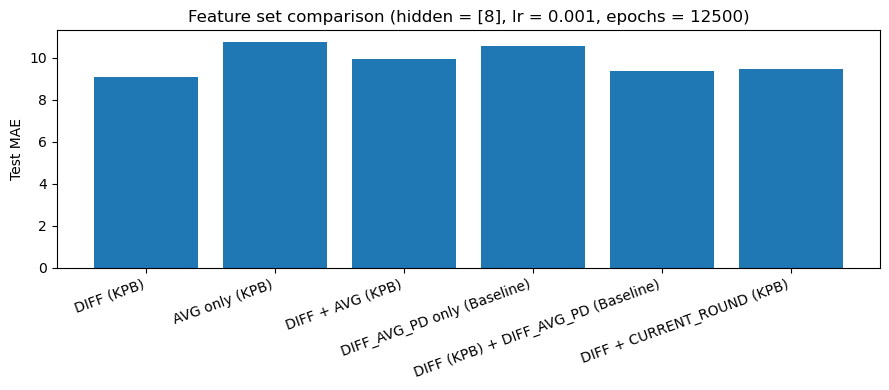

In [28]:
hidden = [8]
layer_activations = ["relu"] * len(hidden)
lr = 1e-3
epochs = 12500

def train_and_eval(X_tr, y_tr, X_te, y_te, label):
    np.random.seed(42)
    w, b, hidden_acts = MLP_train_regression(
        X_tr, y_tr,
        hidden_layer_sizes=hidden,
        learning_rate=lr,
        epochs=epochs,
        layer_activations=layer_activations,
        batch_size=None,
        lr_decay=0.0,
        l2_reg=0.0,
        verbose=1000
    )
    preds_test = MLP_predict_regression(X_te, w, b, activations=hidden_acts)
    mae = float(np.mean(np.abs(preds_test - y_te)))
    rmse = float(np.sqrt(np.mean((preds_test - y_te) ** 2)))
    return {"feature_set": label, "test_mae": mae, "test_rmse": rmse}

rows = []
# DIFF (KPB)
rows.append(train_and_eval(X_train, y_train, X_test, y_test, "DIFF (KPB)"))

# AVG-only features (KPB)
rows.append(train_and_eval(X_train_avg_only, y_train_avg_only, X_test_avg_only, y_test_avg_only, "AVG only (KPB)"))

# DIFF + AVG (KPB)
rows.append(train_and_eval(X_train_diff_avg, y_train_diff_avg, X_test_diff_avg, y_test_diff_avg, "DIFF + AVG (KPB)"))

# DIFF_AVG_PD only (Baseline)
rows.append(train_and_eval(X_train_baseline, y_train_baseline, X_test_baseline, y_test_baseline, "DIFF_AVG_PD only (Baseline)"))

# DIFF (KPB) + DIFF_AVG_PD (Baseline)
rows.append(train_and_eval(X_train_baseline_and_diff, y_train_baseline_and_diff, X_test_baseline_and_diff, y_test_baseline_and_diff, "DIFF (KPB) + DIFF_AVG_PD (Baseline)"))

# DIFF + CURRENT_ROUND (KPB)
rows.append(train_and_eval(X_train_round, y_train_round, X_test_round, y_test_round, "DIFF + CURRENT_ROUND (KPB)"))

feat_df = pd.DataFrame(rows)
display(feat_df)

plt.figure(figsize=(9, 4))
plt.bar(feat_df["feature_set"], feat_df["test_mae"])
plt.ylabel("Test MAE")
plt.title(f"Feature set comparison (hidden = {hidden}, lr = {lr:g}, epochs = {epochs})")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [29]:
# final params for predictions: hidden=[8], activation=relu, lr=1e-3, epochs=12500
from pathlib import Path
Path("Predictions").mkdir(exist_ok=True)

np.random.seed(42)

# Train on DIFF (KPB) feature set
weights, biases, hidden_activations = MLP_train_regression(
    X_train,
    y_train,
    hidden_layer_sizes=[8],
    learning_rate=1e-3,
    epochs=12500,
    layer_activations=["relu"],
    batch_size=None,
    lr_decay=0.0,
    l2_reg=0.0,
    verbose=1000,
)

# predict for ALL matchups (train + test years)
X_all = scaler.transform(matchup_df[feature_cols].to_numpy(dtype=float))
pred_all = np.asarray(MLP_predict_regression(X_all, weights, biases, activations=hidden_activations)).reshape(-1)

preds_out = matchup_df[["YEAR", "CURRENT_ROUND", "TEAM1", "TEAM2", "POINT_DIFFERENTIAL"]].copy()
preds_out["SPLIT"] = np.where(preds_out["YEAR"].isin(train_year_list), "train", "test")
preds_out["PRED_MARGIN"] = pred_all
preds_out["ABS_ERROR"] = (preds_out["POINT_DIFFERENTIAL"] - preds_out["PRED_MARGIN"]).abs()
preds_out["SQ_ERROR"] = (preds_out["POINT_DIFFERENTIAL"] - preds_out["PRED_MARGIN"]) ** 2

out_path = "Predictions/mlp.csv"
preds_out.to_csv(out_path, index=False)

print("Saved:", out_path)
display(preds_out.head())

print("Overall MAE:")
print("train", preds_out.loc[preds_out["SPLIT"] == "train", "ABS_ERROR"].mean())
print("test", preds_out.loc[preds_out["SPLIT"] == "test", "ABS_ERROR"].mean())

print("Overall RMSE:")
print("train", np.sqrt(preds_out.loc[preds_out["SPLIT"] == "train", "SQ_ERROR"].mean()))
print("test", np.sqrt(preds_out.loc[preds_out["SPLIT"] == "test", "SQ_ERROR"].mean()))

epoch:  0  train MAE:  11.965774370747368
epoch:  1000  train MAE:  9.06363067332344
epoch:  2000  train MAE:  8.991461977657897
epoch:  3000  train MAE:  8.987597873558883
epoch:  4000  train MAE:  8.990704748021459
epoch:  5000  train MAE:  8.986390693421873
epoch:  6000  train MAE:  8.967893823125374
epoch:  7000  train MAE:  8.946085350754256
epoch:  8000  train MAE:  8.913986238151624
epoch:  9000  train MAE:  8.882057104709656
epoch:  10000  train MAE:  8.867415282078142
epoch:  11000  train MAE:  8.857248248295491
epoch:  12000  train MAE:  8.850336183350501
Saved: Predictions/mlp.csv


,YEAR,CURRENT_ROUND,TEAM1,TEAM2,POINT_DIFFERENTIAL,SPLIT,PRED_MARGIN,ABS_ERROR,SQ_ERROR
0,2008,2,Memphis,Kansas,-7,train,-2.250289,4.749711,22.559757
1,2008,4,UCLA,Memphis,-15,train,-0.772958,14.227042,202.408733
2,2008,4,Kansas,North Carolina,18,train,6.851529,11.148471,124.288414
3,2008,8,Xavier,UCLA,-19,train,-6.285380,12.714620,161.661570
4,2008,8,Texas,Memphis,-18,train,-7.195149,10.804851,116.744802


Overall MAE:
train 8.84891989178957
test 9.096996122776567
Overall RMSE:
train 11.276616315233413
test 11.410201975922293
